# Min-Variance + XGBoost Tilt — FF5 Factor Risk Model

**Pipeline overview:**
1. Load prices for `shared_set_2` using the toolkit
2. Build toolkit features for the XGBoost tilt signal
3. Retrieve train / val / test split boundaries
4. Estimate Fama-French 5-factor betas on the **training window only**
5. Build the factor covariance matrix Σ = BFBᵀ + D with Ledoit-Wolf shrinkage
6. Solve for minimum-variance weights using `cvxpy`
7. Train an XGBoost quintile classifier on the training window to rank stocks
8. Generate a tilt signal from the last validation-period snapshot and apply it
9. Emit two static `PortfolioWeights` objects — **weights are set once, no rebalancing**
10. Backtest both strategies against SPY and inspect metrics
11. Log to MLflow

> **No-rebalancing note:** All modelling uses only data available before `test_start`.
> The resulting weight vector is fixed for the entire test period.

## 0. Install Extra Dependencies

The toolkit is already installed (notebook runs from inside the repo).
We only need to install the packages the toolkit does not pull in.

In [50]:
import subprocess, sys
from pathlib import Path

# Walk up from MODELS/Eamon to the repo root and install the toolkit
repo_root = Path.cwd()  # MODELS/Eamon -> MODELS -> repo root
print(f"Repo root: {repo_root}")

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "-e", str(repo_root) + "[dev]"
])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "xgboost", "cvxpy", "pandas-datareader"
])

print("Install complete")
%cd /Users/eamonnavin/Portfolio-Optimization-Lib/

Repo root: /Users/eamonnavin/Portfolio-Optimization-Lib
Install complete
/Users/eamonnavin/Portfolio-Optimization-Lib


In [2]:
%cd /Users/eamonnavin/Portfolio-Optimization-Lib/
!pip install -e ".[dev]"

/Users/eamonnavin/Portfolio-Optimization-Lib
Obtaining file:///Users/eamonnavin/Portfolio-Optimization-Lib
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for portfolio-toolkit (pyproject.toml) ... done
  Created wheel for portfolio-toolkit: filename=portfolio_toolkit-0.1.0-0.editable-py3-none-any.whl size=2718 sha256=3cdf05832bf9f8911b65aac29ae6fb765fa29a037d803426090dda759d0519f4
  Stored in directory: /private/var/folders/q7/5c3tl8l906v2bwh035_68mt00000gn/T/pip-ephem-wheel-cache-n4kph7hr/wheels/81/9b/e9/e28fe73c1c74307a0b47d0f88c1d4898250928d6ecf2f91951
Successfully built portfolio-toolkit
  Attempting uninstall: portfolio-toolkit
    Found existing installation: portfolio-toolkit 0.1.0
    Uninstalling portfolio-toolkit-0.1.0:
      Successfully uninstalled portfolio-toolkit-0.1.0


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import cvxpy as cp
import mlflow
import pandas_datareader as pdr
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

from portfolio_toolkit import (
    load_prices,
    build_features,
    make_forward_return_target,
    slice_split,
    split_dates,
    validate_weights_frame,
    backtest_weights,
    build_metrics,
    write_backtest_artifacts,
    baseline_weights,
    init_mlflow,
    start_run,
    log_portfolio,
    log_backtest,
    PortfolioWeights,
)

print("Imports OK")

Imports OK


In [29]:
import portfolio_toolkit.backtest as _bt_module
import pandas as pd

def _fixed_align_weights_to_prices(weights, price_index):
    aligned_rows = []
    aligned_index = []
    for date_value, row in weights.sort_index().iterrows():
        requested = pd.Timestamp(date_value)
        position = price_index.searchsorted(requested, side="left")
        if position >= len(price_index):
            continue
        aligned_rows.append(row)
        aligned_index.append(pd.Timestamp(price_index[position]))
    if not aligned_rows:
        raise ValueError("no weight rows align to the available trading calendar")
    aligned = pd.DataFrame(aligned_rows, index=pd.DatetimeIndex(aligned_index))
    aligned.index.name = "date"
    aligned = aligned.groupby(level=0).last()
    # Fix: renormalise before validation to absorb floating point drift
    aligned = aligned.div(aligned.sum(axis=1), axis=0)
    return _bt_module.validate_weights_frame(aligned)

_bt_module._align_weights_to_prices = _fixed_align_weights_to_prices
print("Patch applied")

Patch applied


## 1. Configuration

All tuneable parameters live here.

`ALPHA` controls how far the XGBoost tilt is allowed to move weights away from the minimum-variance solution. Keep it small — the min-var backbone should do the heavy lifting.

In [30]:
DATASET_NAME  = "shared_set_1"
HORIZON       = 15     # forward-return horizon for the XGBoost target (trading days)
FF_WINDOW     = 252    # rolling window for Fama-French beta estimation (trading days)
ALPHA         = 0.02   # tilt magnitude — fraction of weight budget XGBoost can move
MAX_WEIGHT    = 0.15   # maximum weight in any single stock
MIN_WEIGHT    = 0.0    # long-only

TILT_FEATURE_NAMES = [
    # Momentum — multi-horizon
  # "momentum_5d",
    "momentum_20d",
    "momentum_60d",
  #  "momentum_120d",
    # Short-term reversal
    "return_1d",
    # Volatility / risk
    "vol_20d",
    "vol_60d",
    "downside_vol_20d",
    "atr_14",
#   "beta_20d_spy",
    # Technical oscillators
    "rsi_14",
    "bollinger_z_20d",
    "macd_hist",
    # Price vs moving average
    "price_to_sma_20d",
    "price_to_sma_50d",
    "price_to_sma_200d",
    # Benchmark-relative
    "excess_return_20d_vs_spy",
    "excess_return_60d_vs_spy",
    "relative_momentum_20d_vs_spy",
    # Volume / liquidity
 #   "volume_zscore_20d",
 #   "dollar_volume_ratio_20d",
    # Distribution
    "skew_20d",
    "kurtosis_20d",
]

print(f"Dataset       : {DATASET_NAME}")
print(f"Horizon       : {HORIZON}d")
print(f"FF window     : {FF_WINDOW}d")
print(f"Tilt alpha    : {ALPHA}")
print(f"Max weight    : {MAX_WEIGHT}")
print(f"Tilt features : {len(TILT_FEATURE_NAMES)}")

Dataset       : shared_set_1
Horizon       : 15d
FF window     : 252d
Tilt alpha    : 0.02
Max weight    : 0.15
Tilt features : 18


## 2. Load Prices

In [31]:
prices = load_prices(DATASET_NAME)

# SPY is the benchmark — exclude it from the investable universe
portfolio_tickers = sorted([t for t in prices["ticker"].unique() if t != "SPY"])
N = len(portfolio_tickers)

print(f"Price rows      : {len(prices):,}")
print(f"All tickers     : {sorted(prices['ticker'].unique())}")
print(f"Portfolio N     : {N}  ->  {portfolio_tickers}")
print(f"Date range      : {prices['date'].min().date()} -> {prices['date'].max().date()}")

# Wide adj_close for covariance estimation
adj_close = (
    prices.pivot(index="date", columns="ticker", values="adj_close")
    .sort_index()
)
returns_wide = adj_close.pct_change().dropna(how="all")

prices.head()

Price rows      : 1,460,587
All tickers     : ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APP', 'APTV', 'ARE', 'ARES', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BF-B', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CASY', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CEG', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CIEN', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COHR', 'COIN', 'COO', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRH', 'CRL', 'CRM', 'CRWD', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CTSH', 'CTVA', 'CVNA', 'CVS', 'CVX', 'D', 'DAL', 'D

,date,ticker,open,high,low,close,adj_close,volume
0,2014-01-02,A,40.844063,40.844063,40.164520,40.207439,36.303501,2678848
1,2014-01-03,A,40.336197,41.022888,40.243206,40.715309,36.762058,2609647
2,2014-01-06,A,41.058655,41.273247,40.457798,40.515022,36.581223,2484665
3,2014-01-07,A,40.736767,41.223175,40.722462,41.094421,37.104351,2045554
4,2014-01-08,A,41.008583,41.874107,40.894135,41.766811,37.711468,3717981


## 3. Retrieve Split Boundaries

All modelling is performed exclusively on the **training window**.
The validation window is used only for XGBoost early stopping and the final tilt signal snapshot.
The test window is never touched until the final backtest.

In [32]:
splits = split_dates(DATASET_NAME)
train_start, train_end = splits["train"]
val_start,   val_end   = splits["val"]
test_start,  test_end  = splits["test"]

print(f"Train : {train_start.date()} -> {train_end.date()}")
print(f"Val   : {val_start.date()}   -> {val_end.date()}")
print(f"Test  : {test_start.date()}  -> {test_end.date()}")

train_returns = returns_wide.loc[train_start:train_end]

Train : 2014-01-02 -> 2019-12-31
Val   : 2020-01-02   -> 2021-12-31
Test  : 2022-01-03  -> 2025-12-31


## 4. Fama-French 5-Factor Covariance Matrix

We decompose the covariance matrix as **Sigma = B @ F @ B.T + D** where:

- **B** (N x 5) — factor loadings from OLS regression of each stock's excess returns on FF5 factors
- **F** (5 x 5) — factor covariance, estimated with Ledoit-Wolf shrinkage
- **D** (N x N diagonal) — idiosyncratic variance per stock from regression residuals

All estimation uses only the **training window** to prevent any look-ahead into the test period.

In [33]:
# 4a. Download Fama-French 5-Factor daily returns
print("Downloading FF5 factors from Ken French data library...")
ff5_raw = pdr.get_data_famafrench(
    "F-F_Research_Data_5_Factors_2x3_daily",
    start=str(train_start.date()),
    end=str(train_end.date()),
)[0]
ff5 = ff5_raw / 100.0
ff5.index = pd.to_datetime(ff5.index)

FACTOR_COLS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
rf      = ff5["RF"]
factors = ff5[FACTOR_COLS]

print(f"FF5 rows : {len(factors):,}  ({factors.index.min().date()} -> {factors.index.max().date()})")
factors.tail(3)

FF5 rows : 1,510  (2014-01-02 -> 2019-12-31)


,Mkt-RF,SMB,HML,RMW,CMA
Date,,,,,
2019-12-27,-0.0009,-0.0055,-0.0007,0.0025,0.0015
2019-12-30,-0.0057,0.0029,0.0056,0.0012,0.0042
2019-12-31,0.0028,0.0002,0.0011,-0.0012,0.0021


In [34]:
print("train_returns date range:", train_returns.index.min(), "->", train_returns.index.max())
print("factors date range:", factors.index.min(), "->", factors.index.max())
print("common_dates count:", len(common_dates))
print("est_returns shape:", est_returns.shape)
print("est_factors shape:", est_factors.shape)
print("est_rf shape:", est_rf.shape)

train_returns date range: 2014-01-03 00:00:00 -> 2019-12-31 00:00:00
factors date range: 2014-01-02 00:00:00 -> 2019-12-31 00:00:00
common_dates count: 1509
est_returns shape: (252, 503)
est_factors shape: (252, 5)
est_rf shape: (252,)


In [35]:
# 4b. Estimate factor loadings B (N x 5)
# Use the last FF_WINDOW trading days of training — the most recent view before test begins.

common_dates = train_returns.index.intersection(factors.index)
est_returns  = train_returns.loc[common_dates].iloc[-FF_WINDOW:]
est_factors  = factors.loc[common_dates].iloc[-FF_WINDOW:]
est_rf       = rf.loc[common_dates].iloc[-FF_WINDOW:]

B_rows     = {}  # ticker -> 5-vector of factor loadings
resid_vars = {}  # ticker -> idiosyncratic variance

for ticker in portfolio_tickers:
    if ticker not in est_returns.columns:
        continue
    y    = est_returns[ticker].values - est_rf.values
    X    = est_factors.values
    mask = ~(np.isnan(y) | np.isnan(X).any(axis=1))
    if mask.sum() < 60:
        print(f"  WARNING: {ticker} only {mask.sum()} clean obs — skipping")
        continue
    reg = LinearRegression(fit_intercept=True).fit(X[mask], y[mask])
    B_rows[ticker]     = reg.coef_
    residuals          = y[mask] - reg.predict(X[mask])
    resid_vars[ticker] = np.var(residuals, ddof=len(FACTOR_COLS) + 1)

fitted_tickers = list(B_rows.keys())
B        = np.array([B_rows[t]     for t in fitted_tickers])  # N x 5
idio_var = np.array([resid_vars[t] for t in fitted_tickers])  # N
D        = np.diag(idio_var)                                   # N x N

beta_df = pd.DataFrame(B, index=fitted_tickers, columns=FACTOR_COLS)
beta_df["idio_ann_vol"] = np.sqrt(idio_var * 252)
print(f"Factor loadings B : {B.shape}")
print(f"Fitted tickers    : {fitted_tickers}")
print("\nFactor betas:")
beta_df.round(3)

Factor loadings B : (485, 5)
Fitted tickers    : ['A', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APTV', 'ARE', 'ARES', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BF-B', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CASY', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CIEN', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COHR', 'COO', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRH', 'CRL', 'CRM', 'CRWD', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CTSH', 'CTVA', 'CVNA', 'CVS', 'CVX', 'D', 'DAL', 'DD', 'DDOG', 'DE', 'DECK', 'DELL', '

,Mkt-RF,SMB,HML,RMW,CMA,idio_ann_vol
A,1.336,-0.062,-0.142,-0.765,0.865,0.183
AAPL,1.387,-0.075,-0.258,0.913,-0.599,0.170
ABBV,1.018,-0.101,-0.368,-0.213,0.728,0.244
ABT,1.084,-0.274,-0.525,-0.567,0.607,0.138
ACGL,0.884,-0.336,0.018,-0.522,0.708,0.143
...,...,...,...,...,...,...
XYZ,1.616,-0.147,-0.281,-0.125,-2.248,0.314
YUM,0.545,-0.506,-0.319,0.183,0.412,0.136
ZBH,0.941,0.152,-0.469,-0.883,0.991,0.179
ZBRA,1.122,1.399,-0.406,0.917,-1.452,0.300


Sigma shape      : (485, 485)
Min eigenvalue   : 1.81e-05  (>= 0 means valid PSD matrix)
Condition number : 1990.0


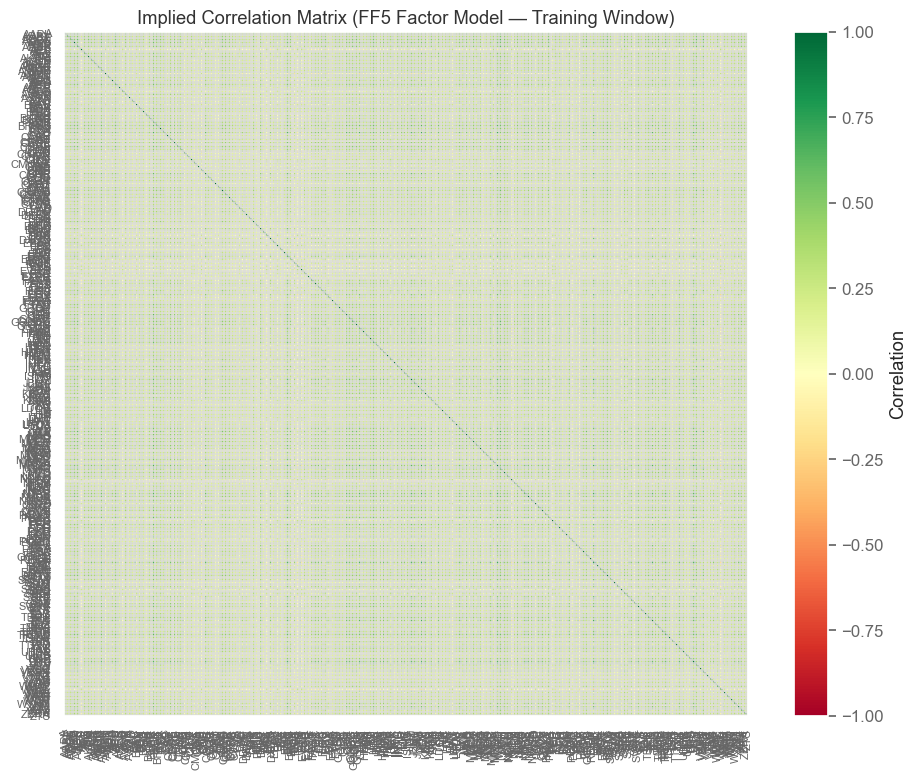

In [36]:
# 4c. Factor covariance F (5 x 5) with Ledoit-Wolf shrinkage
lw = LedoitWolf().fit(est_factors)
F  = lw.covariance_  # 5 x 5

# 4d. Assemble full covariance matrix
Sigma = B @ F @ B.T + D  # N x N

# Sanity check: all eigenvalues should be >= 0
eigenvalues = np.linalg.eigvalsh(Sigma)
print(f"Sigma shape      : {Sigma.shape}")
print(f"Min eigenvalue   : {eigenvalues.min():.2e}  (>= 0 means valid PSD matrix)")
print(f"Condition number : {eigenvalues.max() / max(eigenvalues.min(), 1e-12):.1f}")

# Implied correlation matrix
vol  = np.sqrt(np.diag(Sigma))
corr = Sigma / np.outer(vol, vol)
np.fill_diagonal(corr, 1.0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(fitted_tickers)))
ax.set_yticks(range(len(fitted_tickers)))
ax.set_xticklabels(fitted_tickers, rotation=90, fontsize=8)
ax.set_yticklabels(fitted_tickers, fontsize=8)
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Implied Correlation Matrix (FF5 Factor Model — Training Window)")
plt.tight_layout()
plt.show()

## 5. Minimum-Variance Optimisation

Solve:
```
minimise    w.T @ Sigma @ w
subject to  sum(w) == 1
            MIN_WEIGHT <= w_i <= MAX_WEIGHT  for all i
```
No return forecasts enter this step — the optimizer is purely risk-driven.

In [37]:
n = len(fitted_tickers)
w = cp.Variable(n)

objective   = cp.Minimize(cp.quad_form(w, Sigma))
constraints = [
    cp.sum(w) == 1,
    w >= MIN_WEIGHT,
    w <= MAX_WEIGHT,
]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.CLARABEL)

assert problem.status in ("optimal", "optimal_inaccurate"), f"Solver failed: {problem.status}"

w_minvar = pd.Series(w.value, index=fitted_tickers).clip(0)
w_minvar = w_minvar / w_minvar.sum()  # re-normalise after clip

ann_vol_minvar = np.sqrt(w_minvar.values @ Sigma @ w_minvar.values * 252)
print(f"Solver status       : {problem.status}")
print(f"Portfolio ann. vol  : {ann_vol_minvar:.2%}")
print(f"\nMin-var weights:")
print(w_minvar.sort_values(ascending=False).round(4).to_string())

Solver status       : optimal
Portfolio ann. vol  : 4.94%

Min-var weights:
VRT      0.1500
PSA      0.0612
EXR      0.0528
EVRG     0.0411
NEM      0.0358
MTB      0.0271
DUK      0.0268
CBOE     0.0246
SPG      0.0233
HSY      0.0214
AWK      0.0208
SO       0.0201
WEC      0.0200
MLM      0.0198
AEP      0.0196
HBAN     0.0177
ED       0.0174
KEY      0.0166
SW       0.0165
DTE      0.0160
CMS      0.0160
NEE      0.0157
CCI      0.0153
ES       0.0150
DOC      0.0144
WMT      0.0128
MAA      0.0126
SJM      0.0123
VICI     0.0109
KR       0.0108
CPT      0.0104
REG      0.0100
NVR      0.0100
EQR      0.0099
ETR      0.0095
SYY      0.0091
AVB      0.0090
VMC      0.0089
EIX      0.0089
WELL     0.0086
INVH     0.0086
CASY     0.0085
MKC      0.0084
CFG      0.0075
BLDR     0.0073
AMT      0.0070
FOX      0.0067
FOXA     0.0066
FITB     0.0060
PHM      0.0054
VTR      0.0051
DPZ      0.0043
LNT      0.0041
CHRW     0.0040
D        0.0039
UDR      0.0037
IRM      0.0037
AEE      0.0

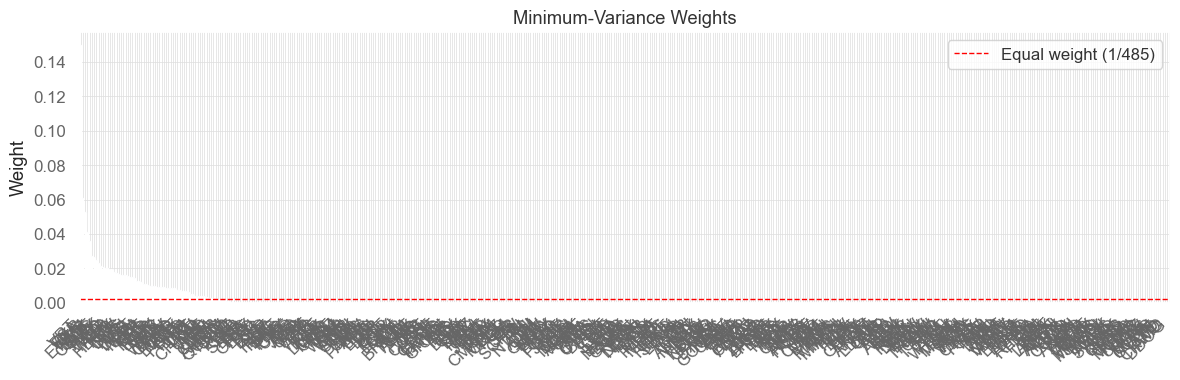

In [38]:
fig, ax = plt.subplots(figsize=(12, 4))
w_minvar.sort_values(ascending=False).plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(1 / n, color="red", linestyle="--", linewidth=1, label=f"Equal weight (1/{n})")
ax.set_title("Minimum-Variance Weights")
ax.set_ylabel("Weight")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Build Tilt Features + Quintile Target

XGBoost is trained to **rank** stocks, not to predict exact returns. The target is which cross-sectional quintile each stock falls into over the next `HORIZON` days (0 = bottom, 4 = top).

All features are cross-sectionally rank-normalised within each date so they are comparable across stocks regardless of market regime.

In [39]:
features   = build_features(prices, feature_names=TILT_FEATURE_NAMES)
target_ret = make_forward_return_target(prices, horizon=HORIZON)
target_col = f"forward_return_{HORIZON}d"
  
panel = (
    features
    .merge(target_ret[["date", "ticker", target_col]], on=["date", "ticker"], how="inner")
    .dropna(subset=TILT_FEATURE_NAMES + [target_col])
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

# Remove SPY — benchmark only
panel = panel[panel["ticker"] != "SPY"].copy()

# Cross-sectional quintile target (computed within each date's cross-section)
panel["quintile"] = (
    panel.groupby("date")[target_col]
    .transform(lambda x: pd.qcut(x.rank(method="first"), 5, labels=False))
    .astype(int)
)

# Cross-sectional rank-normalise features (pct rank within each date)
for feat in TILT_FEATURE_NAMES:
    panel[feat] = (
        panel.groupby("date")[feat]
        .transform(lambda x: x.rank(pct=True))
    )

print(f"Panel rows after cleaning : {len(panel):,}")
print(f"Quintile distribution:")
print(panel["quintile"].value_counts().sort_index().to_string())
panel.head()

Panel rows after cleaning : 1,349,408
Quintile distribution:
quintile
0    270877
1    269388
2    269459
3    269388
4    270296


,date,ticker,momentum_20d,momentum_60d,return_1d,vol_20d,vol_60d,downside_vol_20d,atr_14,rsi_14,...,price_to_sma_20d,price_to_sma_50d,price_to_sma_200d,excess_return_20d_vs_spy,excess_return_60d_vs_spy,relative_momentum_20d_vs_spy,skew_20d,kurtosis_20d,forward_return_15d,quintile
0,2014-10-16,A,0.228070,0.267544,0.407895,0.594298,0.563596,0.521930,0.368421,0.296053,...,0.175439,0.225877,0.210526,0.228070,0.267544,0.228070,0.796053,0.438596,0.118454,3
1,2014-10-17,A,0.199561,0.291667,0.464912,0.554825,0.537281,0.541667,0.375000,0.127193,...,0.144737,0.203947,0.195175,0.199561,0.291667,0.199561,0.739035,0.300439,0.094703,2
2,2014-10-20,A,0.182018,0.265351,0.201754,0.530702,0.526316,0.572368,0.392544,0.096491,...,0.098684,0.175439,0.179825,0.182018,0.265351,0.182018,0.717105,0.282895,0.109053,3
3,2014-10-21,A,0.210526,0.324561,0.809211,0.585526,0.557018,0.578947,0.412281,0.122807,...,0.153509,0.195175,0.197368,0.210526,0.324561,0.210526,0.752193,0.260965,0.078531,3
4,2014-10-22,A,0.149123,0.282895,0.188596,0.557018,0.574561,0.576754,0.416667,0.142544,...,0.122807,0.162281,0.177632,0.149123,0.282895,0.149123,0.833333,0.427632,0.092311,3


## 7. Train / Val Split for XGBoost

Splits are strictly chronological using the shared toolkit boundaries. The test set is never touched here.

In [40]:
train_panel = slice_split(panel, DATASET_NAME, "train")
val_panel   = slice_split(panel, DATASET_NAME, "val")

X_train = train_panel[TILT_FEATURE_NAMES]
y_train = train_panel["quintile"]
X_val   = val_panel[TILT_FEATURE_NAMES]
y_val   = val_panel["quintile"]

for name, split in [("train", train_panel), ("val", val_panel)]:
    print(f"{name:6s}: {len(split):6,} rows  "
          f"({split['date'].min().date()} -> {split['date'].max().date()})")

train : 613,486 rows  (2014-10-16 -> 2019-12-31)
val   : 245,422 rows  (2020-01-02 -> 2021-12-31)


## 8. Train XGBoost Quintile Classifier

In [41]:
model = xgb.XGBClassifier(
    objective             = "multi:softprob",
    num_class             = 5,
    n_estimators          = 400,
    max_depth             = 4,      # shallow — limits overfitting on noisy return data
    learning_rate         = 0.01,
    subsample             = 0.7,
    colsample_bytree      = 0.7,
    min_child_weight      = 15,     # higher = more conservative splits
    reg_lambda            = 2.0,    # L2
    reg_alpha             = 0.5,    # L1
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
    early_stopping_rounds = 30,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

val_acc   = accuracy_score(y_val, model.predict(X_val))
naive_acc = 1 / 5
print(f"Val accuracy    : {val_acc:.4f}")
print(f"Naive baseline  : {naive_acc:.4f}  (random 5-class)")
print(f"Best iteration  : {model.best_iteration}")

Val accuracy    : 0.2404
Naive baseline  : 0.2000  (random 5-class)
Best iteration  : 399


Feature importance (gain):
vol_60d                         0.2674
vol_20d                         0.1182
downside_vol_20d                0.0915
price_to_sma_200d               0.0466
kurtosis_20d                    0.0457
momentum_20d                    0.0455
excess_return_20d_vs_spy        0.0407
price_to_sma_20d                0.0386
relative_momentum_20d_vs_spy    0.0375
atr_14                          0.0371
price_to_sma_50d                0.0359
skew_20d                        0.0351
momentum_60d                    0.0300
return_1d                       0.0296
excess_return_60d_vs_spy        0.0286
bollinger_z_20d                 0.0269
rsi_14                          0.0232
macd_hist                       0.0218


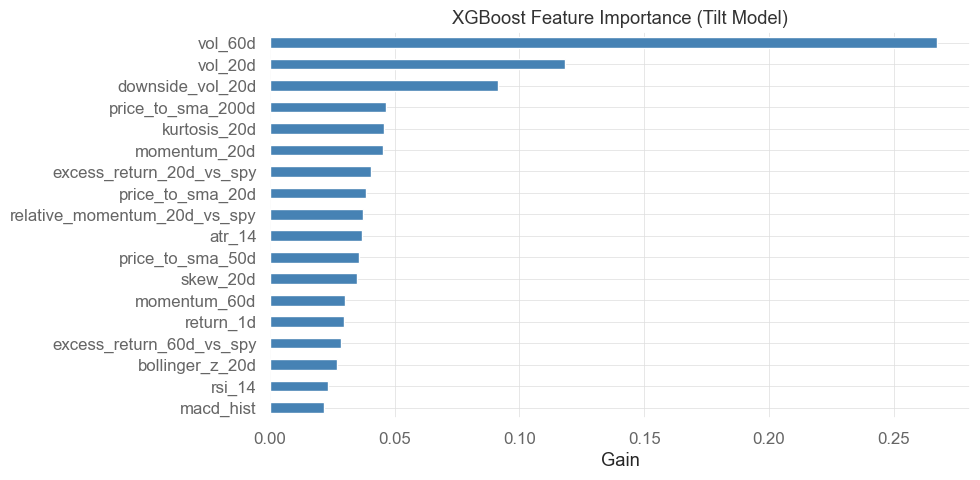

In [43]:
importance = (
    pd.Series(model.feature_importances_, index=TILT_FEATURE_NAMES)
    .sort_values(ascending=False)
)
print("Feature importance (gain):")
print(importance.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
importance.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost Feature Importance (Tilt Model)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.show()

## 9. Generate Tilt Signal and Apply to Min-Variance Weights

The signal is the predicted **probability of landing in the top quintile** (class 4) for each stock.

It is computed from the **last date in the validation panel** — the most recent snapshot of features before the test window opens. This is the only date that matters since weights are assigned once and never rebalanced.

The signal is centred, scaled by `ALPHA`, added to the min-var weights, then clipped and re-normalised.

In [45]:
signal_date = val_panel["date"].max()
snapshot    = (
    val_panel[val_panel["date"] == signal_date]
    .copy()
    .set_index("ticker")
)
# Keep only tickers that appear in both the snapshot and Sigma
snapshot = snapshot[snapshot.index.isin(fitted_tickers)]

print(f"Signal date         : {signal_date.date()}")
print(f"Tickers in snapshot : {sorted(snapshot.index.tolist())}")

# Predict top-quintile probability for each stock
proba      = model.predict_proba(snapshot[TILT_FEATURE_NAMES])
top_q_prob = pd.Series(proba[:, 4], index=snapshot.index, name="top_q_prob")

# Align to the min-var weight index, fill missing tickers with mean
signal = top_q_prob.reindex(w_minvar.index).fillna(top_q_prob.mean())

# Centre (dollar-neutral: adds to some, subtracts from others)
signal = signal - signal.mean()

# Scale to ALPHA
delta_w = signal / signal.abs().sum() * ALPHA if signal.abs().sum() > 0 else signal * 0

# Apply, clip, re-normalise
w_tilted = (w_minvar + delta_w).clip(lower=MIN_WEIGHT, upper=MAX_WEIGHT)
w_tilted = w_tilted / w_tilted.sum()

print(f"\nMax absolute weight shift : {(w_tilted - w_minvar).abs().max():.4f}")
print(f"Weight sum                : {w_tilted.sum():.6f}")
print(f"Min / max weight          : {w_tilted.min():.4f} / {w_tilted.max():.4f}")

Signal date         : 2021-12-31
Tickers in snapshot : ['A', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APTV', 'ARE', 'ARES', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BF-B', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CASY', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CIEN', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COHR', 'COO', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRH', 'CRL', 'CRM', 'CRWD', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CTSH', 'CTVA', 'CVNA', 'CVS', 'CVX', 'D', 'DAL', 'DD', 'DDOG', 'DE', 'DECK', 'DE

Weight comparison:
       min_var  tilted   delta  signal
VRT     0.1500  0.1489 -0.0011  0.0589
PSA     0.0612  0.0607 -0.0005 -0.0593
EXR     0.0528  0.0524 -0.0004 -0.0287
EVRG    0.0411  0.0408 -0.0004 -0.0620
NEM     0.0358  0.0355 -0.0003 -0.0354
MTB     0.0271  0.0269 -0.0002  0.0376
DUK     0.0268  0.0265 -0.0003 -0.0652
CBOE    0.0246  0.0244 -0.0002 -0.0210
SPG     0.0233  0.0231 -0.0002  0.0097
HSY     0.0214  0.0212 -0.0002 -0.0707
AWK     0.0208  0.0206 -0.0002 -0.0693
SO      0.0201  0.0199 -0.0002 -0.0716
WEC     0.0200  0.0198 -0.0002 -0.0455
MLM     0.0198  0.0197 -0.0002 -0.0203
AEP     0.0196  0.0193 -0.0002 -0.0696
HBAN    0.0177  0.0176 -0.0001  0.0473
ED      0.0174  0.0173 -0.0002 -0.0695
KEY     0.0166  0.0165 -0.0001  0.0055
SW      0.0165  0.0165 -0.0000  0.1102
DTE     0.0160  0.0158 -0.0002 -0.0645
CMS     0.0160  0.0158 -0.0002 -0.0540
NEE     0.0157  0.0155 -0.0002 -0.0471
CCI     0.0153  0.0151 -0.0002 -0.0533
ES      0.0150  0.0148 -0.0002 -0.0667
DOC   

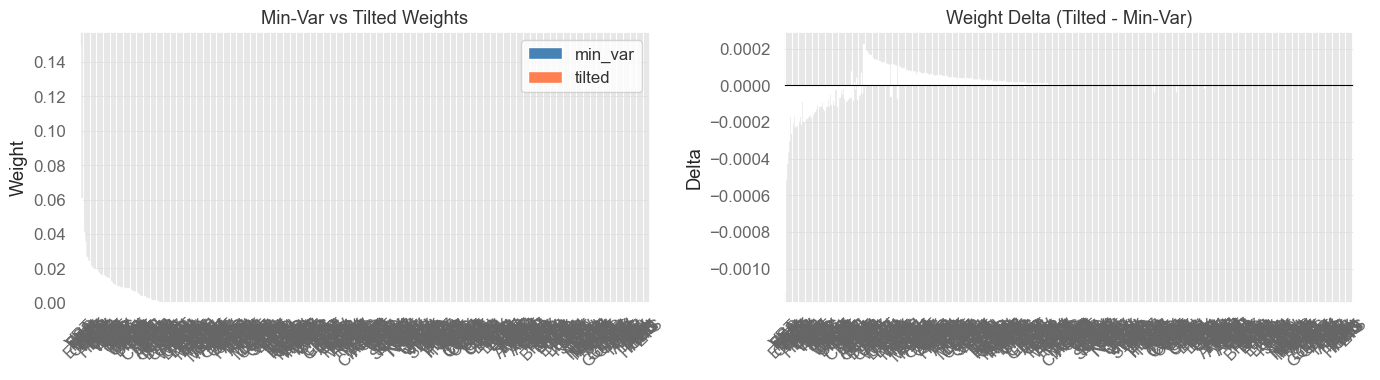

In [46]:
comparison = pd.DataFrame({
    "min_var" : w_minvar,
    "tilted"  : w_tilted,
    "delta"   : w_tilted - w_minvar,
    "signal"  : (top_q_prob - top_q_prob.mean()).reindex(w_minvar.index),
}).sort_values("tilted", ascending=False)

print("Weight comparison:")
print(comparison.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
comparison[["min_var", "tilted"]].plot(
    kind="bar", ax=axes[0], color=["steelblue", "coral"]
)
axes[0].set_title("Min-Var vs Tilted Weights")
axes[0].set_ylabel("Weight")
axes[0].tick_params(axis="x", rotation=45)

comparison["delta"].plot(
    kind="bar", ax=axes[1],
    color=["green" if x > 0 else "red" for x in comparison["delta"]]
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Weight Delta (Tilted - Min-Var)")
axes[1].set_ylabel("Delta")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 10. Emit PortfolioWeights Objects

The toolkit's `validate_weights_frame` expects a **wide DataFrame** with dates as the index and tickers as columns. A single-row frame is passed — the backtest layer broadcasts static weights across the full test period.

In [47]:
def make_static_portfolio(weight_series, strategy_name, metadata=None):
    w = weight_series.clip(lower=MIN_WEIGHT, upper=MAX_WEIGHT)
    w = w / w.sum()
    residual = 1.0 - w.sum()
    w.iloc[w.argmax()] += residual

    weights_wide = pd.DataFrame(
        [w.values],
        index=pd.DatetimeIndex([test_start]),
        columns=w.index,
        
    )
    weights_wide = validate_weights_frame(weights_wide, dataset_name=DATASET_NAME)
    print(w.sum())
    return PortfolioWeights(
        weights       = weights_wide,
        dataset_name  = DATASET_NAME,
        strategy_name = strategy_name,
        metadata      = metadata or {},
    )

portfolio_minvar = make_static_portfolio(
    w_minvar,
    strategy_name = "minvar_ff5",
    metadata      = {"type": "minvar", "ff_window": FF_WINDOW, "alpha": 0.0},
)

portfolio_tilted = make_static_portfolio(
    w_tilted,
    strategy_name = "minvar_xgb_tilt",
    metadata      = {"type": "minvar+tilt", "ff_window": FF_WINDOW, "alpha": ALPHA},
)

print("Min-var portfolio:")
print(portfolio_minvar.weights.round(4).to_string())
print("\nTilted portfolio:")
print(portfolio_tilted.weights.round(4).to_string())

1.0
1.0
Min-var portfolio:
              A  AAPL  ABBV  ABT  ACGL  ACN  ADBE  ADI  ADM  ADP  ADSK    AEE     AEP  AES  AFL  AIG  AIZ  AJG  AKAM  ALB  ALGN  ALL  ALLE  AMAT    AMCR  AMD  AME  AMGN  AMP    AMT  AMZN  ANET  AON  AOS  APA  APD  APH  APO  APTV  ARE  ARES     ATO    AVB  AVGO  AVY     AWK  AXON  AXP  AZO   BA  BAC  BALL  BAX  BBY  BDX  BEN  BF-B   BG  BIIB   BK  BKNG  BKR    BLDR  BLK  BMY   BR  BRK-B  BRO  BSX   BX  BXP    C  CAG  CAH    CASY  CAT   CB    CBOE  CBRE     CCI  CCL  CDNS  CDW   CF     CFG     CHD   CHRW  CHTR   CI  CIEN  CINF   CL  CLX  CMCSA  CME  CMG  CMI    CMS  CNC  CNP  COF  COHR  COO  COP  COR  COST  CPAY  CPB  CPRT     CPT  CRH  CRL  CRM  CRWD  CSCO  CSGP  CSX  CTAS    CTRA  CTSH  CTVA  CVNA  CVS  CVX       D  DAL   DD  DDOG   DE  DECK  DELL   DG  DGX  DHI  DHR  DIS  DLR  DLTR     DOC  DOV  DOW     DPZ  DRI    DTE     DUK  DVA  DVN  DXCM   EA  EBAY  ECL      ED  EFX   EG     EIX   EL  ELV  EME  EMR  EOG  EPAM  EQIX     EQR  EQT  ERIE     ES  ESS  ETN   

## 11. Backtest

Both strategies are evaluated over the test period. Because weights are static, turnover is zero — costs apply only at the initial entry on `test_start`.

In [51]:
result_minvar = backtest_weights(DATASET_NAME, portfolio_minvar)
result_tilted = backtest_weights(DATASET_NAME, portfolio_tilted)

metrics_minvar = build_metrics(result_minvar)
metrics_tilted = build_metrics(result_tilted)

output_dir = repo_root / "runs" / "xgb_portfolio"
output_dir.mkdir(parents=True, exist_ok=True)

artifact_paths_minvar = write_backtest_artifacts(result_minvar, output_dir)
artifact_paths_tilted = write_backtest_artifacts(result_tilted, output_dir)

metrics_df = pd.DataFrame({
    "Min-Var FF5"        : metrics_minvar,
    "Min-Var + XGB Tilt" : metrics_tilted,
}).T

print("=== Test-Period Metrics ===")
print(metrics_df.to_string())

=== Test-Period Metrics ===
                    evaluation_years  evaluation_trading_days  total_return  annual_return  annual_volatility    sharpe   sortino  max_drawdown    calmar  average_turnover  benchmark_total_return  benchmark_annual_return  benchmark_annual_volatility  benchmark_sharpe  benchmark_max_drawdown  excess_return_vs_benchmark  annual_excess_return_vs_benchmark  sharpe_vs_benchmark
Min-Var FF5                 3.991786                   1003.0      1.043288       0.196030           0.237548  0.825224  1.089093     -0.324162  0.604729               1.0                0.507582                 0.108312                     0.179691          0.602767               -0.244964                    0.535707                           0.087718             0.222457
Min-Var + XGB Tilt          3.991786                   1003.0      1.042055       0.195849           0.237478  0.824703  1.088532     -0.324118  0.604252               1.0                0.507582                 0.108312

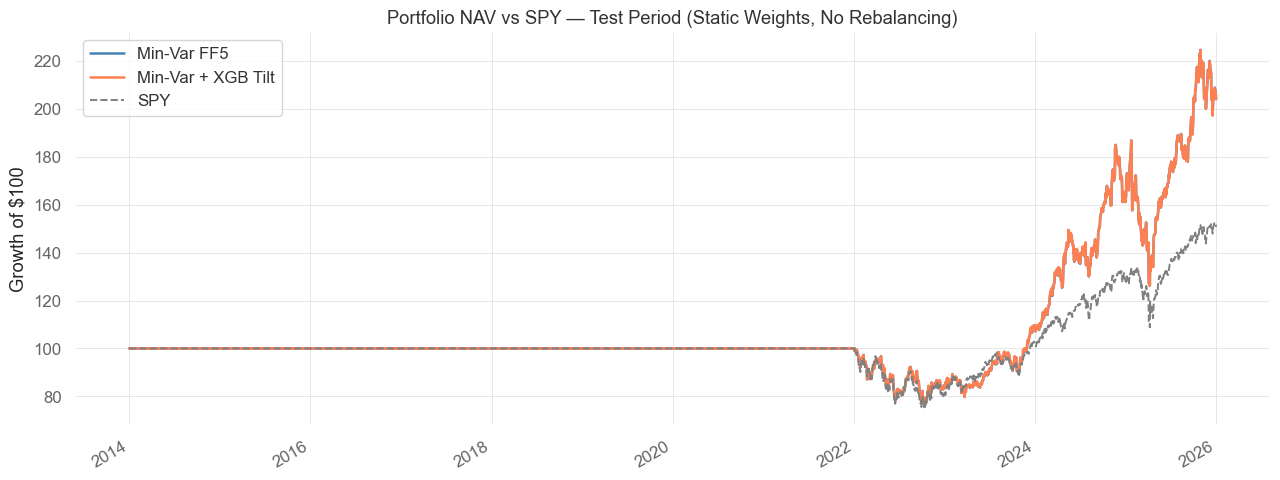

In [52]:
fig, ax = plt.subplots(figsize=(13, 5))
result_minvar.nav.rename("Min-Var FF5").plot(ax=ax, color="steelblue", linewidth=1.8)
result_tilted.nav.rename("Min-Var + XGB Tilt").plot(ax=ax, color="coral", linewidth=1.8)

spy_nav = (1 + result_minvar.benchmark_returns.iloc[:, 0]).cumprod() * 100
spy_nav.rename("SPY").plot(ax=ax, linestyle="--", color="gray", linewidth=1.4)

ax.set_title("Portfolio NAV vs SPY — Test Period (Static Weights, No Rebalancing)")
ax.set_ylabel("Growth of $100")
ax.legend()
plt.tight_layout()
plt.show()

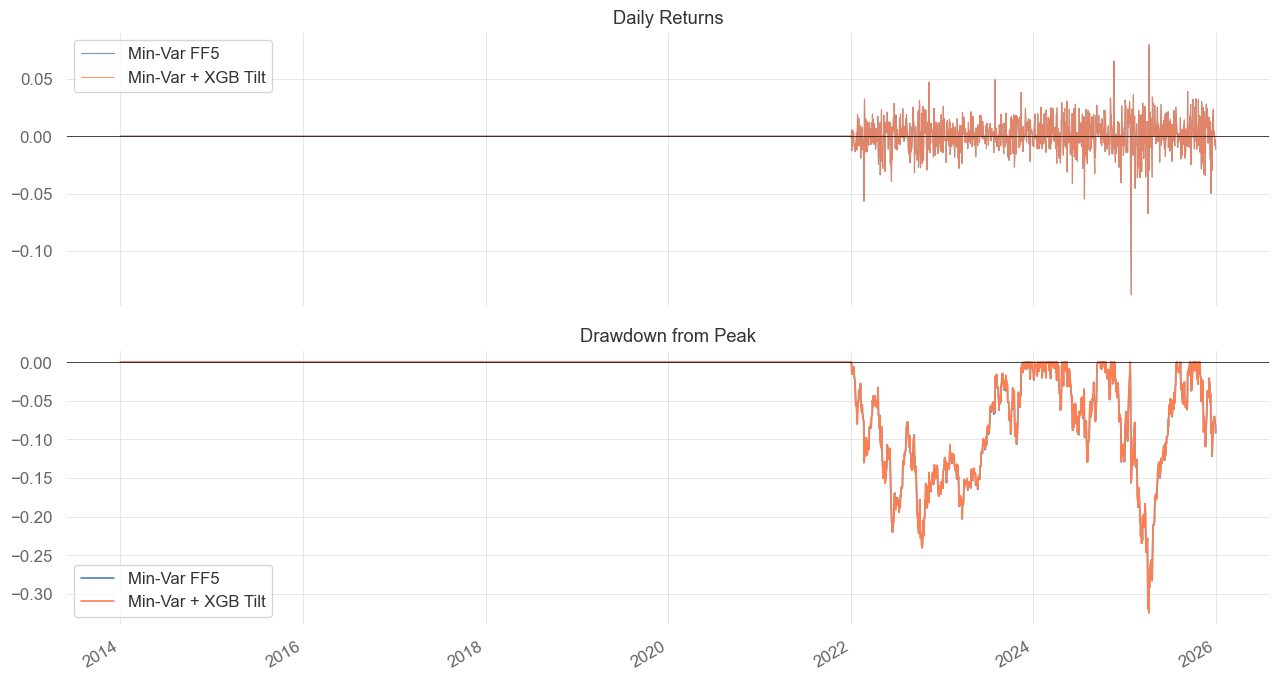

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for result, label, color in [
    (result_minvar, "Min-Var FF5",        "steelblue"),
    (result_tilted, "Min-Var + XGB Tilt", "coral"),
]:
    nav         = result.nav
    drawdown    = (nav - nav.cummax()) / nav.cummax()
    result.returns.rename(label).plot(ax=axes[0], color=color, alpha=0.8, linewidth=0.8)
    drawdown.rename(label).plot(ax=axes[1], color=color, linewidth=1.2)

axes[0].set_title("Daily Returns")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].legend()
axes[1].set_title("Drawdown from Peak")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].legend()
plt.tight_layout()
plt.show()

## 12. Log to MLflow

In [54]:
model.save_model("model.json")

In [66]:
mlflow.end_run()

🏃 View run bemused-wolf-742 at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/0/runs/8e38926d1adc4f0b99b336e7ded0ad69
🧪 View experiment at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/0


In [65]:
from portfolio_toolkit import log_model_submission
init_mlflow()

shared_params = {
    "dataset_name" : DATASET_NAME,
    "horizon"      : HORIZON,
    "ff_window"    : FF_WINDOW,
    "n_stocks"     : len(fitted_tickers),
    "max_weight"   : MAX_WEIGHT,
    "rebalancing"  : "none",
}
shared_params = {
    "dataset_name" : DATASET_NAME,
    "horizon"      : HORIZON,
    "ff_window"    : FF_WINDOW,
    "n_stocks"     : len(fitted_tickers),
    "max_weight"   : MAX_WEIGHT,
    "rebalancing"  : "none",
}

model_name = "minvar_xgb_tilt_wk2"
feature_names = TILT_FEATURE_NAMES
horizon = HORIZON
rebalance_frequency = "none"
model_artifact_path = output_dir / f"{model_name}.json"
model.save_model(model_artifact_path)


# Run 1: Min-Var baseline
#with start_run(
#    run_name     = "minvar_ff5_baseline",
#    dataset_name = DATASET_NAME,
#    tags         = {"model": "minvar_ff5", "tilt": "none"},
#):
#    mlflow.log_params({**shared_params, "alpha": 0.0})
#    log_portfolio(portfolio_minvar)
#    log_backtest(result_minvar)

# Run 2: Min-Var + XGBoost Tilt
with start_run(
    run_name     = "minvar_xgb_tilt",
    dataset_name = DATASET_NAME,
    tags         = {"model": "minvar_ff5", "tilt": "xgb_quintile"},
):
    mlflow.log_params({
        **shared_params,
        "alpha"            : ALPHA,
        "xgb_n_estimators" : model.best_iteration,
        "xgb_max_depth"    : 4,
        "xgb_lr"           : 0.01,
        "xgb_features"     : ",".join(TILT_FEATURE_NAMES),
    })
    log_portfolio(portfolio_tilted)
    log_backtest(result_tilted)
manifest = log_model_submission(
        {"model": model_artifact_path},
        model_name=model_name,
        model_family="xgboost",
        feature_names=feature_names,
        target=target_col,
        horizon=horizon,
        rebalance_frequency=rebalance_frequency,
        preprocessing={
            "scaler": "none",
        },
        model_config={
            "library": "xgboost",
            "estimator": "XGBClassifier",
            "artifact_format": "json",
            "rebalance_frequency": rebalance_frequency,
            "portfolio_builder": "weights_from_predictions_rank_long_only",
            "required_functions": ["build_model_features", "predict_from_prices"],
        },
        source_files=[repo_root / "MODELS" / "Eamon" / "minvar_xgb_tilt_wk2.ipynb"],
        notes="Required XGBoost submission with reusable feature and predict functions.",
    )

print("MLflow logging complete.")
#print(json.dumps(manifest, indent=2))




🏃 View run minvar_xgb_tilt at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/2/runs/141207ada6f84df3afedc59cb46ce769
🧪 View experiment at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/2
MLflow logging complete.
